# Imports and data/model preparation

In [1]:
from config import PROCESSED_DATA_DIR, CSV_DATA_DIR, MODELS_DIR, DEVICE, PROJ_ROOT
from script.trainer import Trainer, EarlyStopping
from models.ViT import ViTRegressor
import torch
from torch.utils.data import DataLoader
from script.dataset import MapDataset
from torch.optim import AdamW
from script.visualization import plot_history
import pandas as pd
from script.cross_validation import kfoldCV
import optuna
import joblib
from collections import defaultdict

2025-08-05 23:55:04.317 | INFO     | config:<module>:12 - PROJ_ROOT path is: /home/aislab/princisgh_map_completeness/map_completeness_estimation


## Visualize study parameters

In [2]:
study_file = PROJ_ROOT / 'studies/ViTRegressor-tiny_study'
study : optuna.Study = joblib.load(study_file, 'r')

In [3]:
(df := study.trials_dataframe())[df['state'] == 'COMPLETE']

,number,value,datetime_start,datetime_complete,duration,params_backbone_LR,params_batch_size,params_dropout,params_head_LR,params_head_layer_1,params_head_layer_2,params_num_layers,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,state
0,0,0.044726,2025-08-05 18:23:54.176238,2025-08-05 18:31:08.401885,0 days 00:07:14.225647,0.000001,128,0.3,0.001295,1024,NaN,1,0.002483,0.045106,NaN,COMPLETE
1,1,0.044057,2025-08-05 18:31:13.943316,2025-08-05 18:38:27.830581,0 days 00:07:13.887265,0.000002,128,0.2,0.000057,512,NaN,1,0.003029,0.045641,0.042557,COMPLETE
5,5,0.004571,2025-08-05 18:44:24.960654,2025-08-05 18:52:08.904399,0 days 00:07:43.943745,0.000036,32,0.0,0.000021,1024,256.0,2,0.000183,0.003134,NaN,COMPLETE
6,6,0.014069,2025-08-05 18:52:15.334722,2025-08-05 19:03:48.827050,0 days 00:11:33.492328,0.000570,8,0.0,0.000708,1024,NaN,1,0.000147,0.035566,0.024824,COMPLETE
14,14,0.004479,2025-08-05 19:35:17.346637,2025-08-05 19:43:05.132356,0 days 00:07:47.785719,0.000010,32,0.0,0.000044,1024,128.0,2,0.002427,0.003400,NaN,COMPLETE
15,15,0.004530,2025-08-05 19:43:13.046690,2025-08-05 19:50:19.745301,0 days 00:07:06.698611,0.000002,64,0.0,0.000010,1024,128.0,2,0.003521,0.004468,0.004249,COMPLETE
16,16,0.003303,2025-08-05 19:50:27.868737,2025-08-05 19:57:57.894301,0 days 00:07:30.025564,0.000002,32,0.0,0.000005,1024,128.0,2,0.024500,0.004230,0.003732,COMPLETE
17,17,0.003976,2025-08-05 19:58:05.913601,2025-08-05 20:05:36.914094,0 days 00:07:31.000493,0.000002,32,0.0,0.000004,1024,128.0,2,0.365575,0.003834,NaN,COMPLETE
19,19,0.003905,2025-08-05 20:10:11.580384,2025-08-05 20:17:41.464317,0 days 00:07:29.883933,0.000001,32,0.0,0.000005,1024,128.0,2,0.204739,0.003963,0.003811,COMPLETE
24,24,0.003806,2025-08-05 20:30:42.487274,2025-08-05 20:42:20.678069,0 days 00:11:38.190795,0.000002,8,0.0,0.000008,256,NaN,1,0.261796,0.003423,0.003453,COMPLETE


In [4]:
params = study.best_params
print(params)

{'backbone_LR': 2.0813751179131146e-06, 'head_LR': 4.982644048867052e-06, 'weight_decay': 0.024500008424662767, 'batch_size': 32, 'head_layer_1': 1024, 'num_layers': 2, 'head_layer_2': 128, 'dropout': 0.0}


In [5]:
optuna.visualization.plot_timeline(study)

## Prepare data and model for training

In [6]:
df_train = pd.read_csv(str(CSV_DATA_DIR / 'df_train.csv'))
df_val = pd.read_csv(str(CSV_DATA_DIR / 'df_valid.csv'))
df_test = pd.read_csv(str(CSV_DATA_DIR / 'df_test.csv'))

In [7]:
train_ds = MapDataset(PROCESSED_DATA_DIR / 'train', df_train, task='regression', augment=True)
val_ds = MapDataset(PROCESSED_DATA_DIR / 'valid', df_val, task='regression')
test_ds = MapDataset(PROCESSED_DATA_DIR / 'test', df_test, task='regression')

train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=params['batch_size'], num_workers=8)
test_loader = DataLoader(test_ds, batch_size=params['batch_size'], num_workers=8)

In [ ]:
head_cfg = {
    'hidden_dims' : [1024, 128],
    'dropout_rate': params['dropout']
}
model = ViTRegressor(img_size=224, head_cfg=head_cfg, variant='base')
assert model.variant == 'tiny'

loss = torch.nn.MSELoss()
ES = EarlyStopping(patience=5, restore_best_weights=True)

optim = AdamW([
    {'params': model.MLP.parameters(), 'lr': params['head_LR'], "weight_decay": params['weight_decay']},
    {'params': model.backbone.parameters(), 'lr': params['backbone_LR']}
])

EPOCHS = 15

for param in model.backbone.parameters():
    param.require_grad = True

trainer = Trainer(model, optim, loss)

#scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[10, 20], gamma=0.05)
#trainer.set_scheduler(scheduler)

Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-tiny-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Compute CV loss

In [9]:
CVLoss = kfoldCV(
    trainer, 
    train_ds, 
    num_folds=5, 
    epochs=15, 
    batch_size=params['batch_size'], 
    task="regression", 
    ES=ES
)

print(f"k-Fold CV loss: {CVLoss:.5f}")


Epoch 1/15:   0%|          | 0/361 [00:00<?, ?it/s]

Starting fold 1/5


Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]


Epoch 2/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

...


Epoch 14/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]


Epoch 15/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

Fold 5/5 ended with loss: 0.0060
5-fold CV loss: 0.0056
k-Fold CV loss: 0.00559


## Train classifier

In [10]:
trainer.reset_training()
trainer.train(train_loader, val_loader, 'regression', epochs=EPOCHS, early_stopping=ES)


Epoch 1/15:   0%|          | 0/451 [00:00<?, ?it/s]

[1/15] Train Loss: 0.0148


Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

[1/15] Val Loss: 0.0058 



Epoch 2/15:   0%|          | 0/451 [00:00<?, ?it/s]

...

[6/15] Val Loss: 0.0041 



Epoch 7/15:   0%|          | 0/451 [00:00<?, ?it/s]

[7/15] Train Loss: 0.0029


Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

[7/15] Val Loss: 0.0046 
Stopping training due to EarlyStopping


/home/aislab/princisgh_map_completeness/map_completeness_estimation/src/script/visualization.py:26: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



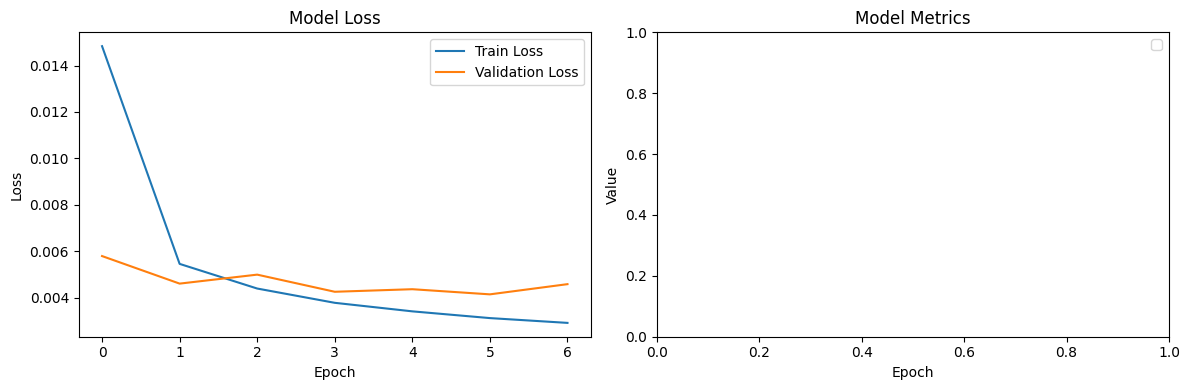

In [11]:
plot_history(trainer.history)

#### Validation Results

In [ ]:
trainer.evaluate(val_loader) # run evaluation in case early stop was triggered
trainer.save_model(MODELS_DIR, 'ViTRegressor-tiny.pt')

Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

Model ViTRegressor_regression.pt saved to /home/aislab/princisgh_map_completeness/map_completeness_estimation/model_weights


# Test result and metrics

In [24]:
import torch.nn as nn

y_hat, y_true, loss = trainer.predict(test_loader)
y_hat, y_true = y_hat.squeeze(), y_true.squeeze()

# map filenames are expected in the format 'id@run@time'
env_id = lambda x: x.split('@')[0]
result_dict = defaultdict(list)
for i in range(len(test_ds)):
    mapname = test_ds.df['id'].iloc[i] 
    result_dict[env_id(mapname)].append(abs(y_hat[i] - y_true[i])) # store the absolute prediction error, grouped by map

average_errors = [(id, sum(lst) / len(lst)) for id, lst in result_dict.items()]

Evaluation:   0%|          | 0/95 [00:00<?, ?it/s]

In [36]:
print("Map completeness percentage prediction results")
for env, err in average_errors:
    print(f"{env:>40} -> {float(err)*100:.2f}%")
print(f"\nAverage: {sum([x[1] for x in average_errors]) / len(average_errors)*100:.2f}%")

Map completeness percentage prediction results
                                     8-1 -> 4.38%
                                   E18-1 -> 5.34%
                                   E60-1 -> 4.12%
                      MediaCache_updated -> 3.83%
                          Rustic_updated -> 1.38%
                       Vipiteno2_updated -> 8.14%
                                    W8-1 -> 3.76%
         ZELLENBOROS_GRUPPENZONE_updated -> 5.37%
                       autoSales_updated -> 1.22%
                                   lab_a -> 8.11%
                                   lab_f -> 4.06%
      modern-office-floor-plan-1_updated -> 3.40%
                                office_b -> 3.79%
 scuola_secondaria_i_grado_mera__updated -> 3.92%
         south_mountain_school_1_updated -> 3.96%

Average: 4.32%
